The following topics are covered in this tutorial:

1.Downloading a real-world dataset from Kaggle

2.Exploratory data analysis and visualization

3.Splitting a dataset into training, validation & test sets

4.Filling/imputing missing values in numeric columns

5.Scaling numeric features to a (0, 1) range

6.Encoding categorical columns as one-hot vectors

7.Training a logistic regression model using Scikit-learn

8.Evaluating a model using a validation set and test set

9.Saving a model to disk and loading it back








In [34]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import plotly.express as px
from IPython.display import Image

In [ ]:
df = pd.read_csv('weatherAUS.csv')
df.head()

RainTomorrow is the target variable to predict. It answers the crucial question: will it rain the next day? (Yes or No)

In [ ]:
df.info()

In [ ]:
df.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)

In [ ]:
df.head()

Let's Check rain possibility according to locations

In [ ]:
px.histogram(df, x='Location', color='RainToday', title='Distribution of Rain Tomorrow')

In [ ]:
px.scatter(df.sample(2000),x='MinTemp',y='MaxTemp',color='RainToday',title='Min Temp vs Max Temp')

we can predict max temp at which it rains using independent variable min temp 

CHECK LR_MAXTEMP BRANCH

Training, Validation and Test Sets

While building real-world machine learning models, it is quite common to split the dataset into three parts:

Training set - used to train the model, i.e., compute the loss and adjust the model's weights using an optimization technique.

Validation set - used to evaluate the model during training, tune model hyperparameters (optimization technique, regularization etc.), and pick the best version of the model. Picking a good validation set is essential for training models that generalize well.

Test set - used to compare different models or approaches and report the model's final accuracy. For many datasets, test sets are provided separately. The test set should reflect the kind of data the model will encounter in the real world, as closely as feasible.



In [ ]:
from sklearn.model_selection import train_test_split

train_val_df,test_df = train_test_split(df,test_size=0.2,random_state=42)
train_df,val_df = train_test_split(train_val_df,test_size=0.25,random_state=42) # 0.25 x 0.8 = 0.2

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

However, while working with dates, it's often a better idea to separate the training, validation and test sets with time, so that the model is trained on data from the past and evaluated on data from the future.



In [ ]:
plt.title('DATA PER YEAR')
sns.countplot(x=pd.to_datetime(df['Date']).dt.year, data=df)

HERE WE GOING TO USE DATA FROM 2018-2014 FOR TRAIN THE MODEL THEN 2014-2015 FOR VALIDATE THE MODEL AND 2015-2016 & 17 FOR TEST THE DATA.

In [ ]:
year = pd.to_datetime(df['Date']).dt.year

train_df = df[year<2015]
val_df = df[year==2015]
test_df = df[year>2015]

TAKING INPUT AND TARGET COLUMNS

In [ ]:
input_cols = list(train_df.columns)[1 : -1 ]
output_cols = 'RainTomorrow'

now we create input and target column for tarining , validation and test

In [ ]:
train_inputs = train_df[input_cols].copy()
train_outputs = train_df[output_cols].copy()

The .copy() method is used to create a new, independent DataFrame instead of just a "view" of the original one. This is crucial for avoiding a common pandas issue called the SettingWithCopyWarning

In [ ]:
val_inputs = val_df[input_cols].copy()
val_outputs = val_df[output_cols].copy()

In [ ]:
test_inputs = test_df[input_cols].copy()    
test_outputs = test_df[output_cols].copy()


LET'S SEPRATE NUMERICAL DATA & CATOGRICAL DATA

In [ ]:
numeric_cols = train_inputs.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object','bool']).columns.tolist()

In [ ]:
train_inputs[numeric_cols].describe()

IMPUTING MISSING TERMS

Machine learning models can't work with missing numerical data. The process of filling missing values is called imputation.

There are several techniques for imputation, but we'll use the most basic one: replacing missing values with the average value in the column using the SimpleImputer class from sklearn.impute.

In [22]:
from sklearn.impute import SimpleImputer    
imputer = SimpleImputer(strategy='mean')


In [23]:
df[numeric_cols].isnull().sum()

MinTemp            468
MaxTemp            307
Rainfall             0
Evaporation      59694
Sunshine         66805
WindGustSpeed     9105
WindSpeed9am      1055
WindSpeed3pm      2531
Humidity9am       1517
Humidity3pm       3501
Pressure9am      13743
Pressure3pm      13769
Cloud9am         52625
Cloud3pm         56094
Temp9am            656
Temp3pm           2624
dtype: int64

In [25]:
imputer.fit(df[numeric_cols])
list(imputer.statistics_)

[np.float64(12.184823865620478),
 np.float64(23.235120301822324),
 np.float64(2.349974074310839),
 np.float64(5.472515506887154),
 np.float64(7.630539861047283),
 np.float64(39.97051988882308),
 np.float64(13.990496092519967),
 np.float64(18.631140782316862),
 np.float64(68.82683277087672),
 np.float64(51.44928834695453),
 np.float64(1017.6545771543716),
 np.float64(1015.2579625879797),
 np.float64(4.431160817585808),
 np.float64(4.499250233195188),
 np.float64(16.987066387879914),
 np.float64(21.693182690011074)]

In [27]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])


In [ ]:
train_inputs[numeric_cols].isnull().sum()
# no Missing values now

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df[numeric_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [30]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])


NOW WHAT IT DOES ACTUALLY IS CONVERT NUMERIC VALUES IN MIN(0s) AND MAX(1s) NAD HENCE WE GET A SERIES DATASET

In [32]:
train_inputs[numeric_cols]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,0.516509,0.523629,0.001617,0.037741,0.526244,0.294574,0.153846,0.275862,0.71,0.22,0.449587,0.4800,0.888889,0.499917,0.508439,0.522073
1,0.375000,0.565217,0.000000,0.037741,0.526244,0.294574,0.030769,0.252874,0.44,0.25,0.497521,0.4912,0.492351,0.499917,0.514768,0.570058
2,0.504717,0.576560,0.000000,0.037741,0.526244,0.310078,0.146154,0.298851,0.38,0.30,0.447934,0.5056,0.492351,0.222222,0.594937,0.548944
3,0.417453,0.620038,0.000000,0.037741,0.526244,0.139535,0.084615,0.103448,0.45,0.16,0.613223,0.5712,0.492351,0.499917,0.533755,0.612284
4,0.613208,0.701323,0.002695,0.037741,0.526244,0.271318,0.053846,0.229885,0.82,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,0.599057,0.718336,0.000000,0.037741,0.526244,0.286822,0.184615,0.298851,0.22,0.13,0.555372,0.5232,0.492351,0.499917,0.651899,0.714012
144549,0.556604,0.786389,0.000000,0.037741,0.526244,0.193798,0.146154,0.229885,0.16,0.08,0.530579,0.4880,0.492351,0.499917,0.761603,0.771593
144550,0.608491,0.805293,0.000000,0.037741,0.526244,0.255814,0.200000,0.103448,0.15,0.08,0.519008,0.4944,0.492351,0.499917,0.778481,0.788868
144551,0.674528,0.818526,0.000000,0.037741,0.526244,0.286822,0.215385,0.195402,0.22,0.09,0.553719,0.5136,0.492351,0.499917,0.780591,0.817658


ENCODING CATEGORICAL DATASETS

Since machine learning models can only be trained with numeric data, we need to convert categorical data to numbers. A common technique is to use one-hot encoding for categorical columns.

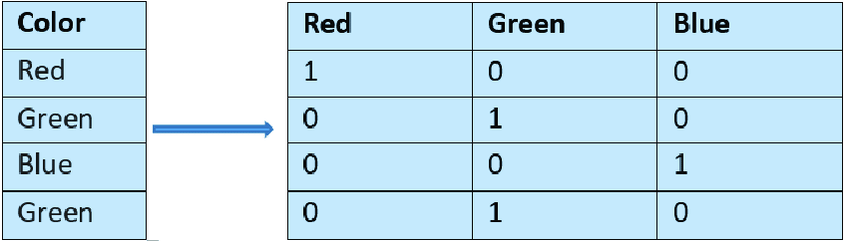

In [35]:
Image('C:\\Users\\Vedant\\Desktop\\TWO DIRECTION\\AIML\\VS CODE\\Logistic-regression\\cat.png') 

In [38]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [40]:
# Get feature names for the encoded columns
encoded_cols = list(encoder.fit(train_inputs[categorical_cols]).get_feature_names_out(categorical_cols))

# Transform categorical data to one-hot encoded arrays
train_encoded = encoder.transform(train_inputs[categorical_cols])
val_encoded = encoder.transform(val_inputs[categorical_cols])
test_encoded = encoder.transform(test_inputs[categorical_cols])

# Create DataFrames from the encoded arrays
train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_inputs.index)
val_encoded_df = pd.DataFrame(val_encoded, columns=encoded_cols, index=val_inputs.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_inputs.index)

# Use pd.concat to efficiently combine the DataFrames
train_inputs = pd.concat([train_inputs, train_encoded_df], axis=1)
val_inputs = pd.concat([val_inputs, val_encoded_df], axis=1)
test_inputs = pd.concat([test_inputs, test_encoded_df], axis=1)

In [41]:
# Remove the original categorical columns since they're now encoded
train_inputs = train_inputs.drop(columns=categorical_cols)
val_inputs = val_inputs.drop(columns=categorical_cols)
test_inputs = test_inputs.drop(columns=categorical_cols)

print("Final dataset shapes:")
print(f"Train inputs: {train_inputs.shape}")
print(f"Validation inputs: {val_inputs.shape}")
print(f"Test inputs: {test_inputs.shape}")

print(f"\nNumber of features: {train_inputs.shape[1]}")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Encoded categorical features: {len(encoded_cols)}")

Final dataset shapes:
Train inputs: (97988, 220)
Validation inputs: (17089, 220)
Test inputs: (25710, 220)

Number of features: 220
Numeric features: 16
Encoded categorical features: 102


In [42]:
test_inputs

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,...,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
2498,0.681604,0.801512,0.000000,0.037741,0.526244,0.372093,0.000000,0.080460,0.46,0.17,0.543802,0.5136,0.777778,0.333333,0.702532,0.808061,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2499,0.693396,0.725898,0.001078,0.037741,0.526244,0.341085,0.069231,0.195402,0.54,0.30,0.505785,0.5008,0.888889,0.888889,0.675105,0.712092,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2500,0.634434,0.527410,0.005930,0.037741,0.526244,0.325581,0.084615,0.448276,0.62,0.67,0.553719,0.6032,0.888889,0.888889,0.611814,0.477927,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2501,0.608491,0.538752,0.042049,0.037741,0.526244,0.255814,0.069231,0.195402,0.74,0.65,0.618182,0.6304,0.888889,0.888889,0.556962,0.518234,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2502,0.566038,0.523629,0.018329,0.037741,0.526244,0.193798,0.046154,0.103448,0.92,0.63,0.591736,0.5888,0.888889,0.888889,0.514768,0.529750,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.283019,0.502836,0.000000,0.037741,0.526244,0.193798,0.115385,0.149425,0.59,0.27,0.730579,0.7056,0.492351,0.499917,0.350211,0.504798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145455,0.266509,0.533081,0.000000,0.037741,0.526244,0.193798,0.100000,0.126437,0.